In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('epl_final.csv')
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [3]:
df.shape

(9380, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   object
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


In [5]:
df.describe()

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


In [6]:
pobede_domacin = df[df['FullTimeResult'] == 'H']['HomeTeam']
pobede_gost = df[df['FullTimeResult'] == 'A']['AwayTeam']

pobede = pd.concat([pobede_domacin, pobede_gost])
pobede_po_timu = pobede.value_counts().head(10)
pobede_po_timu

Man United     552
Arsenal        534
Chelsea        533
Liverpool      530
Man City       500
Tottenham      440
Everton        348
Newcastle      315
Aston Villa    279
West Ham       272
Name: count, dtype: int64

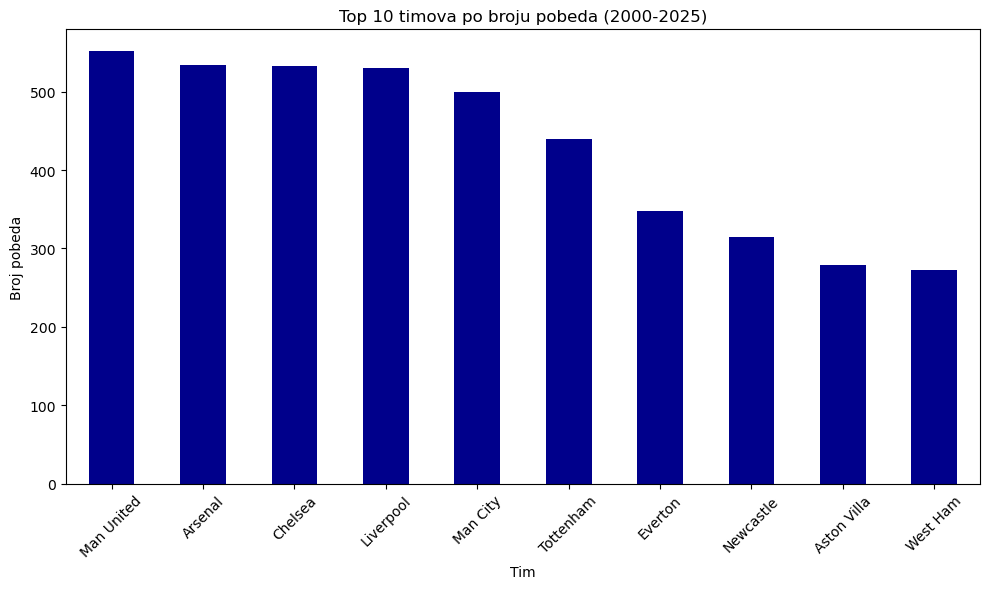

In [8]:
plt.figure(figsize=(10, 6))
pobede_po_timu.plot(kind='bar', color='darkblue')
plt.title('Top 10 timova po broju pobeda (2000-2025)')
plt.xlabel('Tim')
plt.ylabel('Broj pobeda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
golovi_po_sezoni = df.groupby('Season')['FullTimeHomeGoals'].sum() + df.groupby('Season')['FullTimeAwayGoals'].sum()

In [12]:
golovi_po_sezoni

Season
2000/01     992
2001/02    1001
2002/03    1000
2003/04     883
2004/05     851
2005/06     944
2006/07     931
2007/08    1002
2008/09     942
2009/10    1053
2010/11    1063
2011/12    1066
2012/13    1063
2013/14    1052
2014/15     975
2015/16    1026
2016/17    1064
2017/18    1018
2018/19    1072
2019/20    1034
2020/21    1024
2021/22    1071
2022/23    1084
2023/24    1246
2024/25    1038
dtype: int64

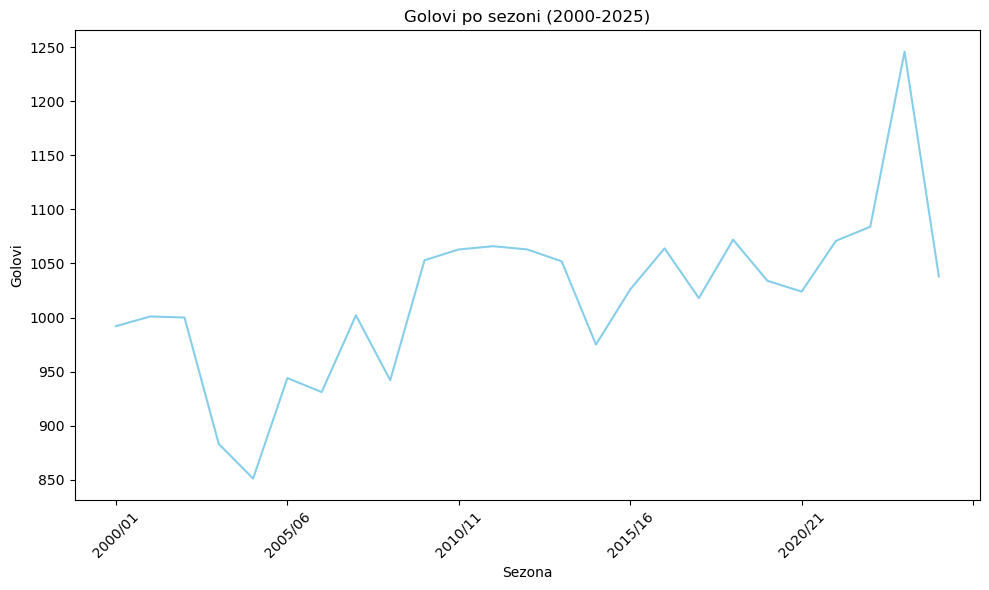

In [13]:
plt.figure(figsize=(10, 6))
golovi_po_sezoni.plot(kind='line', color='skyblue')
plt.title('Golovi po sezoni (2000-2025)')
plt.xlabel('Sezona')
plt.ylabel('Golovi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()